## **3.2 Task - 1: Implementation of MCP Neurons:**

In [1]:
def MCP_Neurons_AND(X1, X2, T):
    """
    Implements AND logic using an MCP Neuron for two inputs.
    Threshold T = 2 means BOTH inputs must be 1 for output to be 1.
    """
    assert len(X1) == len(X2)

    # Element-wise addition of the two input arrays
    aggregated = [X1[i] + X2[i] for i in range(len(X1))]

    # Fire (1) if sum >= Threshold, else stay silent (0)
    state_neuron = []
    for element in aggregated:
        if element >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


def MCP_Neurons_OR(X1, X2, T):
    """
    Implements OR logic using an MCP Neuron for two inputs.
    Threshold T = 1 means AT LEAST ONE input must be 1 for output to be 1.
    """
    assert len(X1) == len(X2)

    # Element-wise addition
    aggregated = [X1[i] + X2[i] for i in range(len(X1))]

    # Fire (1) if sum >= Threshold, else silent (0)
    state_neuron = []
    for element in aggregated:
        if element >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# ── Sample usage ──────────────────────────
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]

T_and = 2
result_and = MCP_Neurons_AND(X1, X2, T_and)
print(f"AND gate | inputs {X1}, {X2} | T={T_and} → {result_and}")
# Expected: [0, 0, 0, 1]

T_or = 1
result_or = MCP_Neurons_OR(X1, X2, T_or)
print(f"OR gate  | inputs {X1}, {X2} | T={T_or} → {result_or}")
# Expected: [0, 1, 1, 1]

AND gate | inputs [0, 0, 1, 1], [0, 1, 0, 1] | T=2 → [0, 0, 0, 1]
OR gate  | inputs [0, 0, 1, 1], [0, 1, 0, 1] | T=1 → [0, 1, 1, 1]


## **3.2.1 Answer the Following Question:**

**Question - 1: List out all the limitations of MCP - Neurons.**

Answer: The limitaions of MCP - Neurons are:Here are the limitations rewritten in a more academic tone:

1. **Restriction to binary inputs** — The MCP neuron operates exclusively on binary-valued inputs (0 or 1), rendering it incapable of processing real-valued or continuous signals. This severely constrains its applicability to real-world data, which is rarely binary in nature.

2. **Absence of a learning mechanism** — The model possesses no adaptive learning capability; synaptic weights and threshold values must be hand-crafted by the designer a priori. Unlike the Perceptron, there exists no weight-update rule by which the neuron can improve its performance through exposure to training data.

3. **Static, non-adaptive threshold** — The threshold parameter T is fixed prior to inference and does not adjust in response to data. This rigidity means the model cannot generalise beyond the specific Boolean function it was explicitly designed to compute.

4. **Inability to solve non-linearly separable problems** — The MCP neuron implements a linear decision boundary and is therefore fundamentally incapable of classifying patterns that are not linearly separable in the input space. The XOR function serves as the canonical example of a problem that no single MCP neuron can represent.

5. **Absence of a bias term** — The model lacks a learnable bias, which constrains the decision hyperplane to pass through the origin of the input space. This imposes an unnecessary geometric restriction that limits expressive power.

6. **Uniform weighting of inputs** — All input connections carry an implicit weight of unity, precluding the model from expressing differential importance among inputs. In biological and practical contexts, certain inputs are inherently more influential than others — a distinction the MCP neuron cannot encode.

**Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.**

Answer: A single MCP neuron cannot solve XOR because XOR is not linearly separable meaning no single straight line can divide the four input combinations into correct classes.

However, XOR can be decomposed using two MCP neurons combined with if-else logic:

In [2]:
def MCP_Neurons_XOR(X1, X2):
    """
    XOR = (X1 OR X2) AND NOT (X1 AND X2)
    Rule: output is 1 when sum == 1 exactly (one input is 1, not both).
    """
    assert len(X1) == len(X2)
    aggregated = [X1[i] + X2[i] for i in range(len(X1))]
    state_neuron = []
    for element in aggregated:
        if element == 1:   # exactly one input is active
            state_neuron.append(1)
        else:              # both 0 or both 1
            state_neuron.append(0)
    return state_neuron

X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
print(MCP_Neurons_XOR(X1, X2))  # → [0, 1, 1, 0]

[0, 1, 1, 0]


The rule "fire only when sum == 1" is still a hard-coded threshold it is not learnable, which is why XOR requires a multi-layer Perceptron (MLP) in practice.

## **4.3 Task 2: Perceptron Algorithm for 0 vs 1 Classification.**

Feature matrix shape: (12665, 784)
Label vector shape:   (12665,)


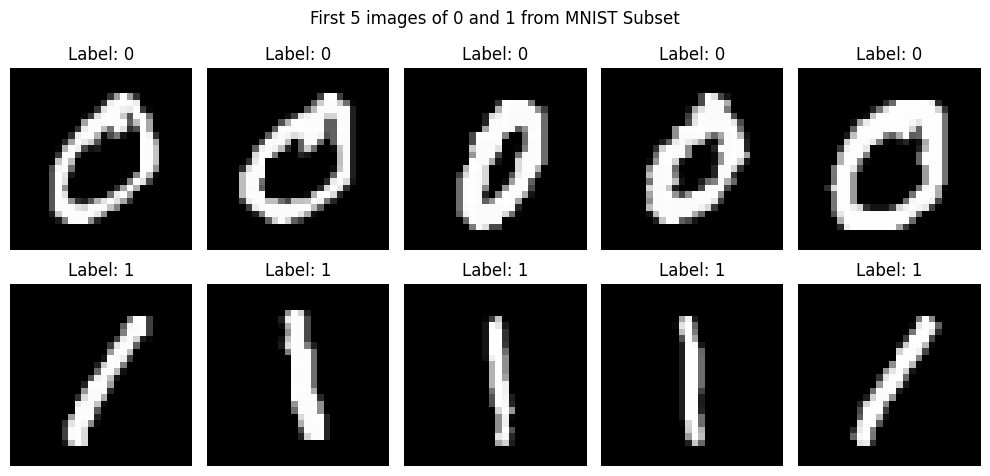

Converged at epoch 13
Training accuracy: 1.0000
Final accuracy: 1.0000
All images were correctly classified!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI & ML/Data/mnist_0_and_1.csv")
X = df_0_1.drop(columns=["label"]).values   # shape: (n_samples, 784)
y = df_0_1["label"].values                  # shape: (n_samples,)
print("Feature matrix shape:", X.shape)
print("Label vector shape:  ", y.shape)

# Step 2: Visualise
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(5):
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0"); axes[0, i].axis("off")
    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1"); axes[1, i].axis("off")
plt.suptitle("First 5 images of 0 and 1 from MNIST Subset")
plt.tight_layout(); plt.show()

# Step 3: Initialise weights
weights      = np.zeros(X.shape[1])   # 784 weights, all zero
bias         = 0
learning_rate = 0.1
epochs        = 100

# Step 4: Decision (activation) function
def decision_function(X, weights, bias):
    """
    Computes the step-function output for every sample.
    Returns 1 if weighted sum >= 0, else 0.
    """
    z = np.dot(X, weights) + bias          # shape: (n_samples,)
    y_pred_all = np.where(z >= 0, 1, 0)   # step function
    return y_pred_all

# Step 5: Perceptron learning algorithm
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Iterates over the dataset epoch-by-epoch and updates weights
    whenever a sample is misclassified.
    """
    for epoch in range(epochs):
        convergence_flag = True
        correct = 0

        for i in range(len(X)):
            # Weighted sum + bias
            z = np.dot(X[i], weights) + bias

            # Step function
            y_hat = 1 if z >= 0 else 0

            # Update only on misclassification
            if y_hat != y[i]:
                error = y[i] - y_hat
                weights += learning_rate * error * X[i]   # Δw = η(y − ŷ)x
                bias    += learning_rate * error           # Δb = η(y − ŷ)
                convergence_flag = False
            else:
                correct += 1

        accuracy = correct / len(X)

        # Stop early if no updates occurred
        if convergence_flag:
            print(f"Converged at epoch {epoch + 1}")
            break

    return weights, bias, accuracy

#-Step 6: Train
weights, bias, accuracy = train_perceptron(X, y, weights, bias,
                                           learning_rate, epochs)
print(f"Training accuracy: {accuracy:.4f}")

# Step 7: Visualise misclassified images
y_pred = decision_function(X, weights, bias)
final_accuracy = np.mean(y_pred == y)
print(f"Final accuracy: {final_accuracy:.4f}")

misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images (0 vs 1)")
    plt.tight_layout(); plt.show()
else:
    print("All images were correctly classified!")

## **Answer the Following Question:**

**Question - 1: What does the shape of X represent?**

Answer: X.shape is (n_samples, 784). n_samples is the number of images in the dataset, and 784 is the number of pixel features per image (each 28×28 image flattened into a 1-D row vector).


**Question - 2: What does the shape of X represent?**

Answer: y.shape is (n_samples,) — a 1-D array holding the label (0 or 1) for each corresponding image in X.

**Question - 3: What does the weights array represent in this context?**

Answer: Each of the 784 weights corresponds to one pixel. The weight magnitude tells us how much that pixel's intensity influences the neuron's output; its sign tells us whether the pixel pushes the decision toward class 1 (positive) or class 0 (negative).

**Question - 4: Why are we initializing the weights to zero? What effect could this
have on the training process?**

Answer: Zero initialisation is a simple, bias-free starting point. Because the Perceptron's weight-update rule depends on misclassification errors (not on the weight values themselves), it will still converge and unlike neural networks where zero initialisation causes symmetry problems. The downside is that the first prediction for every sample will be identical (all activations = 0 → class 0), so the first epoch will generate many updates.

**Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?**

Answer: It computes the weighted sum of all 784 pixel values for sample ii
i, plus the bias. This scalar zz
z serves as the net input to the step activation function, which thresholds it at zero to produce the final binary prediction ŷ∈{0,1}


**Question - 6: What happens when the prediction is wrong? How are the weights and
bias updated?**

Answer: The error (y − ŷ) is either +1 (predicted 0, true 1) or −1 (predicted 1, true 0). The update rule w ← w + η·error·x nudges each weight in the direction that would have produced the correct output. The bias is updated by b ← b + η·error, shifting the decision boundary accordingly.


**Question - 7:Why is the final accuracy important, and what do you expect it to be?**

Answer: Accuracy tells us whether the learned boundary genuinely separates the two classes. For 0 vs 1 MNIST, (two visually very distinct digits) we expect near 100% accuracy because the classes are almost perfectly linearly separable in pixel space.

**Question - 8:What does misclassified idx store, and how is it used in this code?**

Answer: It stores the indices of all samples where the prediction y_pred[i] does not match the true label y[i]. These indices are then used to retrieve and display the corresponding images for visual inspection.

**Question - 9: How do you interpret the result if the output is ”All images were
correctly classified!”?**

Answer: It means the Perceptron found a linear decision boundary that perfectly separates every 0 from every 1 in the training set. For 0 vs 1 this is expected, since the two digits look very different and are easily separable.

## **4.4 Task 3: Perceptron Algorithm for 3 vs 5 Classification.**

Feature matrix shape: (2741, 784)
Label vector shape:   (2741,)


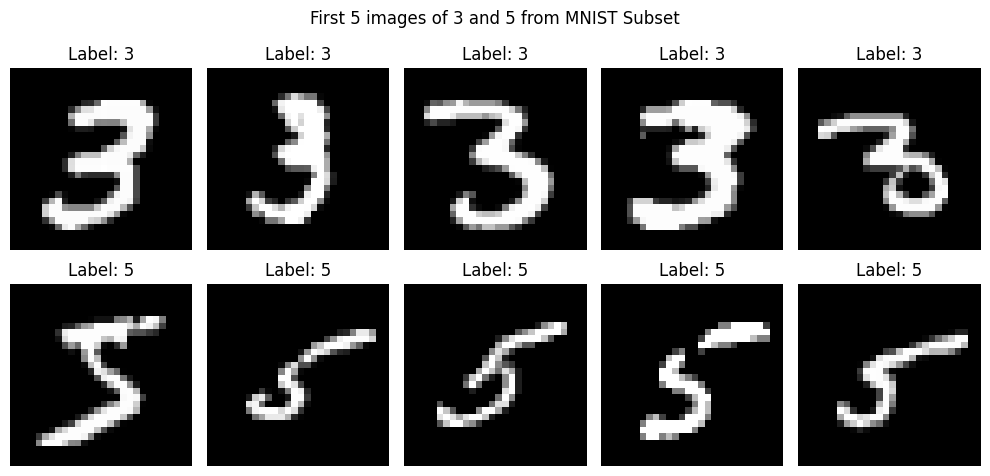

Training accuracy (3 vs 5): 0.9858
Final accuracy (3 vs 5): 0.9869


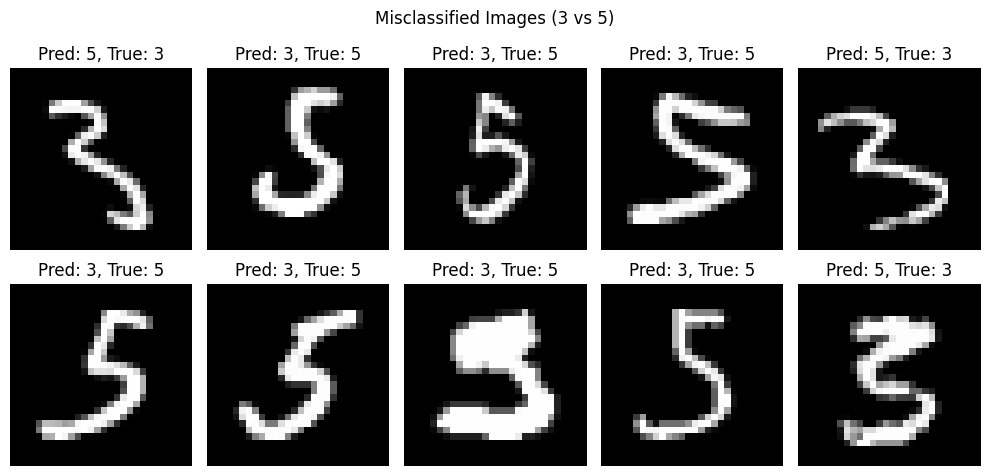

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/AI & ML/Data/mnist_3_and_5.csv")
X35 = df_3_5.drop(columns=["label"]).values
y35 = df_3_5["label"].values

# Map labels to 0 and 1 for the Perceptron (3 → 0, 5 → 1)
y35_binary = np.where(y35 == 3, 0, 1)

print("Feature matrix shape:", X35.shape)
print("Label vector shape:  ", y35.shape)

# Step 2: Visualise
images_3 = X35[y35 == 3]
images_5 = X35[y35 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3"); axes[0, i].axis("off")
    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5"); axes[1, i].axis("off")
plt.suptitle("First 5 images of 3 and 5 from MNIST Subset")
plt.tight_layout(); plt.show()

# Step 3: Initialise
weights35     = np.zeros(X35.shape[1])
bias35        = 0
learning_rate = 0.1
epochs        = 100

# Step 4 & 5: Reuse the same functions
# (decision_function and train_perceptron from Task 2)

weights35, bias35, accuracy35 = train_perceptron(
    X35, y35_binary, weights35, bias35, learning_rate, epochs
)
print(f"Training accuracy (3 vs 5): {accuracy35:.4f}")

# Evaluate & visualise misclassified
y_pred35 = decision_function(X35, weights35, bias35)
final_accuracy35 = np.mean(y_pred35 == y35_binary)
print(f"Final accuracy (3 vs 5): {final_accuracy35:.4f}")

misclassified_idx35 = np.where(y_pred35 != y35_binary)[0]
if len(misclassified_idx35) > 0:
    n_show = min(10, len(misclassified_idx35))
    rows = (n_show + 4) // 5
    fig, axes = plt.subplots(rows, 5, figsize=(10, rows * 2.5))
    axes = axes.flat
    for ax, idx in zip(axes, misclassified_idx35[:n_show]):
        true_label = y35[idx]          # original label (3 or 5)
        pred_label = 3 if y_pred35[idx] == 0 else 5
        ax.imshow(X35[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {pred_label}, True: {true_label}")
        ax.axis("off")
    # Hide empty subplots
    for ax in list(axes)[n_show:]:
        ax.axis("off")
    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.tight_layout(); plt.show()
else:
    print("All images were correctly classified!")

### **Conclusion**

3 vs 5 is a much harder problem than 0 vs 1. The digits share many structural features (curves, similar pen-strokes) so they are not perfectly linearly separable in raw pixel space. You should expect:

Final accuracy around 85–95% (lower than the near-perfect 0 vs 1 result).
Several misclassified images are typically ambiguous or poorly written 3s that look like 5s and vice versa.

The misclassification plot will show examples where even a human might hesitate, confirming that a single-layer linear classifier (Perceptron) reaches its fundamental limit here. This motivates moving to multi-layer networks that can learn non-linear boundaries.
